## Exploratory Data Analysis (EDA)
Datasets explored:
- Raw synthetic supplier-commodity dataset
- Preprocessed synthetic supplier-commodity dataset
- Feature engineered synthetic supplier-commodity dataset

### Raw Synthetic Supplier-Commodity Dataset
The initial dataset generated by ChatGPT with the `synthetic_dataset_prompt.txt`

In [38]:
# Analyse nature of dataset
# Check for missing values, noise, inconsistencies, etc.
# Check for class imbalance
# Identify existing patterns and relationships
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pycountry
import seaborn as sns
from pathlib import Path

DATASET_PATH = Path("../data/raw/syn_supplier_commodity_dataset.csv")

def _load_csv_with_fallback(path: Path) -> pd.DataFrame:
    encodings = ("utf-8", "utf-8-sig", "latin1", "cp1252")
    for encoding in encodings:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, encoding=encodings[-1], encoding_errors="replace")


raw_df = _load_csv_with_fallback(DATASET_PATH)

# This is to ensure that Jupyter doesn't truncate the output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)


In [39]:
# Basic information about the generated dataset
print("==== BASIC INFORMATION ====")
raw_df.info()
print(f"Rows   : {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")

print("\n==== FIRST 5 ROWS ====")
raw_df.head(5)

==== BASIC INFORMATION ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SC_ID                               20000 non-null  object 
 1   Supplier_Name                       20000 non-null  object 
 2   Commodity_Name                      20000 non-null  object 
 3   Year                                20000 non-null  int64  
 4   Month                               20000 non-null  object 
 5   Country                             20000 non-null  object 
 6   Region                              20000 non-null  object 
 7   Supplier_Tier                       20000 non-null  int64  
 8   Industry_Sector                     20000 non-null  object 
 9   ESG_Score                           19801 non-null  float64
 10  Environmental_Score                 20000 non-null  float64
 11  Social_Score 

,SC_ID,Supplier_Name,Commodity_Name,Year,Month,Country,Region,Supplier_Tier,Industry_Sector,ESG_Score,Environmental_Score,Social_Score,Governance_Score,Carbon_Emission_Intensity,GHG_Scope1_Intensity,GHG_Scope2_Intensity,GHG_Scope3_Intensity,Water_Intensity,Waste_Management_Efficiency,Renewable_Energy_Usage,Compliance_Level,Sustainability_Report_Availability,Certifications_Active,Lead_Time_Days,Production_Capacity,On_Time_Delivery_Rate,Defect_Rate,Incident_History_Count,Labour_Compliance_Score,Diversity_Index,Financial_Stability_Score,Freight_Cost,Cost_Index,Commodity_Price_Index,Commodity_Demand,Trade_Volume,Logistics_Distance_km,Risk_Classification
0,SC0000001,Gazprom,Natural gas,2019,January,Russia,Europe and Central Asia,1,Oil and Gas,73.12,70.81,74.25,74.03,0.6432,5.369,1.249,1.015,120.33,0.945,0.720,2,1,Fairtrade,26,10329,0.937,0.000,0,85.84,0.216,85.30,12961.79,0.918,0.973,27705,15527,2377,Moderate
1,SC0000002,ONGC (Oil and Natural Gas Corporation),Crude oil and natural gas,2019,January,India,South Asia,1,Oil and Gas,54.24,71.56,76.76,71.54,0.4605,3.160,1.179,12.892,457.89,0.754,0.000,1,0,NaN,31,5832,0.309,0.029,3,95.06,0.060,60.65,13392.63,1.030,0.811,31905,12770,1057,High
2,SC0000003,TVS Motor Company,"Motorcycles, auto components",2019,January,India,South Asia,1,Automotive,81.85,85.27,70.23,83.98,0.1153,0.444,0.744,2.219,148.67,0.753,0.873,2,1,BRCGS,29,1659,0.874,0.060,0,72.95,0.347,49.56,845.46,0.939,0.908,55191,1248,3036,Moderate
3,SC0000004,Afghan Fruits Ltd./Afghan exporters (examples),"Dried fruits (saffron, dried apricots, nuts)",2019,January,Afghanistan,South Asia,2,Agriculture/Dried Fruits,73.09,63.19,79.47,75.42,0.0888,0.761,0.536,2.140,156.39,0.803,0.230,3,1,LEED; FSSC 22000,20,900,0.921,0.119,0,84.15,0.237,82.10,8908.72,1.267,1.053,62522,5713,3620,Moderate
4,SC0000005,PDVSA (PetrÃ³leos de Venezuela S.A.),Crude oil and petroleum products,2019,January,Venezuela,Latin America and Caribbean,1,Oil and Gas,23.24,42.54,51.20,54.13,0.7805,7.312,2.082,10.134,189.14,0.812,0.531,1,0,NaN,1,1846,0.223,0.060,1,88.90,0.454,60.56,13547.32,0.896,1.043,52362,16856,517,High


In [40]:
# Descriptive analysis
print("\n===== DESCRIPTIVE STATISTICS (NUMERIC) =====")
display(raw_df.describe())

print("\n===== DESCRIPTIVE STATISTICS (CATEGORICAL) =====")
display(raw_df.describe(include='object'))

print("\n===== DATA TYPES =====")
print(raw_df.dtypes)

# Check no. of unique values for each column
print("\n===== UNIQUE VALUES PER COLUMN =====")
print(raw_df.nunique())


===== DESCRIPTIVE STATISTICS (NUMERIC) =====


,Year,Supplier_Tier,ESG_Score,Environmental_Score,Social_Score,Governance_Score,Carbon_Emission_Intensity,GHG_Scope1_Intensity,GHG_Scope2_Intensity,GHG_Scope3_Intensity,Water_Intensity,Waste_Management_Efficiency,Renewable_Energy_Usage,Compliance_Level,Sustainability_Report_Availability,Lead_Time_Days,Production_Capacity,On_Time_Delivery_Rate,Defect_Rate,Incident_History_Count,Labour_Compliance_Score,Diversity_Index,Financial_Stability_Score,Cost_Index,Commodity_Price_Index,Commodity_Demand,Trade_Volume,Logistics_Distance_km
count,20000.000000,20000.000000,19801.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.0000,20000.000000,20000.000000
mean,2021.974550,1.210700,66.394047,66.475511,69.165142,67.815226,0.255105,2.265630,1.020281,3.729622,223.584829,0.577874,0.387860,1.966000,0.689800,26.933000,11334.867700,0.812619,0.044865,0.644250,83.837432,0.334067,71.812770,1.036931,1.038640,35231.7672,12035.216350,3230.664800
std,1.989799,0.407816,12.552493,12.142965,12.457276,12.220188,0.306685,1.659857,0.735392,2.778080,156.179134,0.177669,0.227679,0.736051,0.462587,15.491869,6669.656944,0.161361,0.033116,0.912926,8.723601,0.178761,15.066275,0.290130,0.258366,17598.4873,6299.875963,1742.670928
min,2019.000000,1.000000,13.150000,18.180000,19.920000,22.670000,0.000500,0.010000,0.010000,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.126000,0.000000,0.000000,48.190000,0.003000,14.630000,0.200000,0.300000,1.0000,1.000000,1.000000
25%,2020.000000,1.000000,58.670000,58.110000,60.620000,59.360000,0.083000,1.172750,0.532000,2.009000,124.497500,0.459000,0.221000,1.000000,0.000000,16.000000,6291.000000,0.748000,0.020000,0.000000,77.840000,0.194000,63.050000,0.842000,0.868000,22839.7500,7617.750000,1990.750000
50%,2022.000000,1.000000,66.880000,66.170000,68.840000,67.550000,0.130200,1.849000,0.849000,2.870000,187.895000,0.579000,0.380000,2.000000,1.000000,26.000000,11030.500000,0.860000,0.042000,0.000000,84.000000,0.314000,72.975000,1.026000,1.022000,35125.5000,11950.500000,3206.000000
75%,2024.000000,1.000000,74.910000,74.460000,77.452500,75.980000,0.226500,2.787250,1.287250,4.335000,269.250000,0.698000,0.543000,2.000000,1.000000,36.250000,15873.000000,0.924000,0.064000,1.000000,90.060000,0.455000,82.140000,1.217000,1.187000,47121.2500,16290.250000,4419.000000
max,2025.000000,2.000000,100.000000,100.000000,100.000000,100.000000,1.990000,19.240000,7.438000,32.608000,1229.110000,1.000000,1.000000,3.000000,1.000000,122.000000,36441.000000,1.000000,0.298000,9.000000,100.000000,0.964000,99.000000,2.689000,2.448000,110533.0000,36777.000000,10559.000000



===== DESCRIPTIVE STATISTICS (CATEGORICAL) =====


,SC_ID,Supplier_Name,Commodity_Name,Month,Country,Region,Industry_Sector,Certifications_Active,Freight_Cost,Risk_Classification
count,20000,20000,20000,20000,20000,20000,20000,12546,20000,20000
unique,20000,1359,502,12,125,7,218,382,19783,3
top,SC0000001,Cargill/Louis Dreyfus/ADM (Local Subsidiaries),Crude palm oil,June,United States,Sub-Saharan Africa,Oil and Gas,ISO 9001,14055.23,Moderate
freq,1,127,143,1686,1706,3414,1525,2135,2,11716



===== DATA TYPES =====
SC_ID                                  object
Supplier_Name                          object
Commodity_Name                         object
Year                                    int64
Month                                  object
Country                                object
Region                                 object
Supplier_Tier                           int64
Industry_Sector                        object
ESG_Score                             float64
Environmental_Score                   float64
Social_Score                          float64
Governance_Score                      float64
Carbon_Emission_Intensity             float64
GHG_Scope1_Intensity                  float64
GHG_Scope2_Intensity                  float64
GHG_Scope3_Intensity                  float64
Water_Intensity                       float64
Waste_Management_Efficiency           float64
Renewable_Energy_Usage                float64
Compliance_Level                        int64
Sustainabi

In [41]:
# Types of industries
print("\n===== TYPES OF INDUSTRIES =====")
print(raw_df['Industry_Sector'].value_counts())

# Regions available
print("\n===== ALL REGIONS =====")
print(raw_df['Region'].value_counts())

# Countries available
print("\n===== ALL COUNTRIES =====")
print(raw_df['Country'].value_counts())

# Supplier Tier
print("\n===== ALL SUPPLIER TIERS =====")
print(raw_df['Supplier_Tier'].value_counts())


===== TYPES OF INDUSTRIES =====
Industry_Sector
Oil and Gas                                                1525
Automotive                                                  848
Food Processing                                             586
FMCG                                                        510
Mining                                                      489
Agriculture                                                 475
Semiconductors                                              474
Metals and Mining                                           465
Metals and Minings                                          385
Energy                                                      343
Steel and Materials                                         342
Metals                                                      335
Pharmaceuticals                                             323
Electronics                                                 308
Fertilizers                                            

===== MISSING VALUES =====
Certifications_Active                 7454
ESG_Score                              199
Commodity_Name                           0
Year                                     0
SC_ID                                    0
Supplier_Name                            0
Country                                  0
Month                                    0
Supplier_Tier                            0
Region                                   0
Environmental_Score                      0
Social_Score                             0
Governance_Score                         0
Industry_Sector                          0
GHG_Scope1_Intensity                     0
GHG_Scope2_Intensity                     0
GHG_Scope3_Intensity                     0
Water_Intensity                          0
Waste_Management_Efficiency              0
Renewable_Energy_Usage                   0
Compliance_Level                         0
Carbon_Emission_Intensity                0
Sustainability_Report_Avail

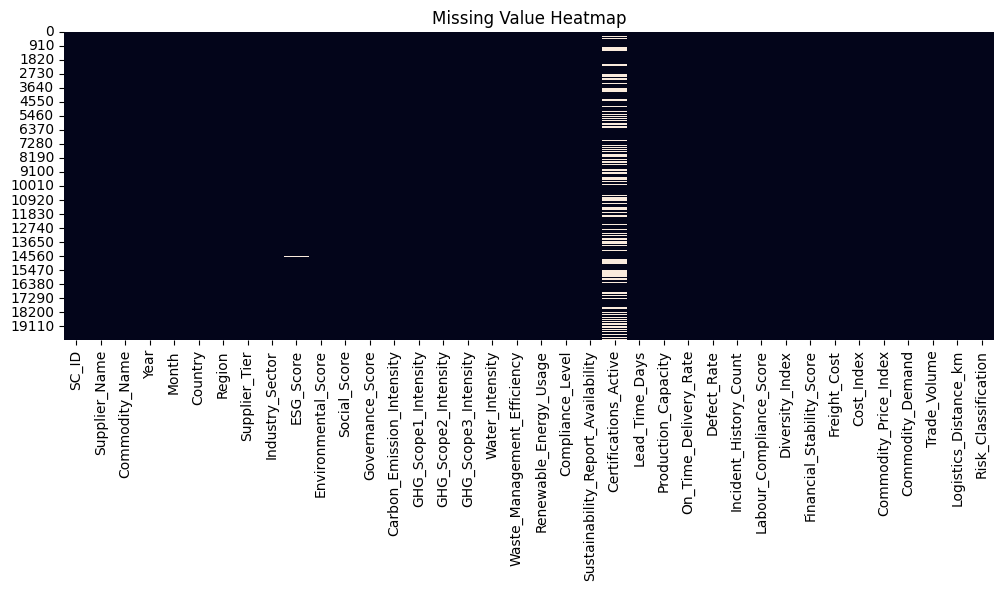

In [42]:
# Check of missing values
print("===== MISSING VALUES =====")
missing = raw_df.isna().sum().sort_values(ascending=False)
print(missing)

plt.figure(figsize=(12,4))
sns.heatmap(raw_df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [43]:
# Check for noise and inconsistencies
print(f"Total no. of duplicated rows: {raw_df.duplicated().sum()}")

# Negative columns
numeric_cols = raw_df.select_dtypes(include=np.number).columns

print("\nNegative Values:")
for col in numeric_cols:
    neg_count = (raw_df[col] < 0).sum()
    if neg_count > 0:
        print(f"Column {col} has {neg_count} negative entries.")
if neg_count == 0:
    print(f"No negative values were found.")

# Check year range
if "Year" in raw_df.columns:
    print(f"\nYear range: {raw_df["Year"].min()} to {raw_df["Year"].max()}")



Total no. of duplicated rows: 0

Negative Values:
No negative values were found.

Year range: 2019 to 2025


In [47]:
# Invalid records (these records will be removed)
def find_invalid_country_records(df, country_col='Country', verbose=True):    
    known_invalid = [
        'Electrical wiring and copper cables',
        'Cobalt sulfate and precursor materials',
        'iron ore',
        'coils',
        'Venezuela/Colombia links',
        'aluminium',
        'ammonia',
        'chemicals',
        'Lithium carbonate and lithium hydroxide',
        'sensors',
        'gold'
    ]
    
    # Get all unique values from Country column
    unique_countries = df[country_col].unique()
    
    # Create set of valid country names using pycountry
    valid_countries = set()
    for country in pycountry.countries:
        valid_countries.add(country.name)
        valid_countries.add(country.alpha_2)
        valid_countries.add(country.alpha_3)
        # Add common alternative names
        if hasattr(country, 'common_name'):
            valid_countries.add(country.common_name)
    
    # Add common variations and alternative names
    common_variations = {
        'USA', 'US', 'United States', 'America',
        'UK', 'United Kingdom', 'Britain',
        'UAE', 'United Arab Emirates',
        'South Korea', 'Korea, Republic of',
        'North Korea', 'Korea, Democratic People\'s Republic of',
        'Russia', 'Russian Federation',
        'Vietnam', 'Viet Nam',
        'Tanzania', 'Tanzania, United Republic of',
        'Iran', 'Iran, Islamic Republic of',
        'Syria', 'Syrian Arab Republic',
        'Venezuela', 'Venezuela, Bolivarian Republic of',
        'Bolivia', 'Bolivia, Plurinational State of',
        'Moldova', 'Moldova, Republic of',
        'Macedonia', 'North Macedonia',
        'Congo', 'Congo, Democratic Republic of the',
        'Ivory Coast', 'Côte d\'Ivoire', 'Turkey', 'Democratic Republic of the Congo', 'Congo',
        'Palestine', 'Czech Republic', 'São Tomé and Príncipe', 'PRC', 'People\'s Republic of China'
    }
    valid_countries.update(common_variations)
    
    # Find invalid entries
    invalid_values = {}
    invalid_indices = []
    
    for idx, value in enumerate(df[country_col]):
        # Check if value is in known invalid list (case-insensitive)
        if any(invalid.upper() in str(value).upper() for invalid in known_invalid):
            invalid_indices.append(idx)
            invalid_values[value] = invalid_values.get(value, 0) + 1
        # Check if value is not in valid countries
        elif str(value).strip() not in valid_countries:
            # Additional checks for edge cases
            if not str(value).strip():  # Empty or whitespace
                continue
            if pd.isna(value):  # NaN values
                continue
            
            invalid_indices.append(idx)
            invalid_values[value] = invalid_values.get(value, 0) + 1
    
    # Create DataFrame with invalid records
    invalid_df = df.iloc[invalid_indices].copy()
    
    if verbose:
        print("="*80)
        print("INVALID COUNTRY RECORDS ANALYSIS")
        print("="*80)
        print(f"\nTotal records in dataset: {len(df):,}")
        print(f"Records with invalid 'Country' values: {len(invalid_df):,}")
        print(f"Percentage of invalid records: {(len(invalid_df)/len(df)*100):.2f}%")
        print(f"\nNumber of unique invalid values: {len(invalid_values)}")
        
        print("\n" + "-"*80)
        print("INVALID VALUES FOUND (sorted by frequency):")
        print("-"*80)
        
        # Sort by count (descending)
        sorted_invalid = sorted(invalid_values.items(), key=lambda x: x[1], reverse=True)
        
        for value, count in sorted_invalid:
            print(f"  • '{value}' - {count:,} occurrences")
        
        print("\n" + "-"*80)
        print("ALL INVALID RECORDS:")
        print("-"*80)
        
        # Display sample of invalid records
        display_cols = ['SC_ID', 'Supplier_Name', 'Country', 'Commodity_Name', 'Region']
        available_cols = [col for col in display_cols if col in invalid_df.columns]
        
        if len(invalid_df) > 0:
            print(invalid_df[available_cols].to_string(index=False))
        else:
            print("No invalid records found.")        
        print("\n" + "="*80)

        print("\n" + "-"*80)
        print("BREAKDOWN BY SUPPLIER:")
        print("-"*80)

        if 'Supplier_Name' in invalid_df.columns and len(invalid_df) > 0:
            # Get unique suppliers with invalid records
            unique_suppliers = invalid_df['Supplier_Name'].unique()
            print(f"\nTotal unique suppliers with invalid records: {len(unique_suppliers)}")
            print("\nSuppliers with invalid country records:")
            for supplier in sorted(unique_suppliers):  # sorted alphabetically
                print(f"  • {supplier}")
    
    return invalid_df, invalid_values, valid_countries

invalid_records, invalid_dict, valid_countries = find_invalid_country_records(raw_df)

# To save invalid records to CSV for further inspection:
invalid_records.to_csv('invalid_country_records.csv', index=False)

INVALID COUNTRY RECORDS ANALYSIS

Total records in dataset: 20,000
Records with invalid 'Country' values: 456
Percentage of invalid records: 2.28%

Number of unique invalid values: 12

--------------------------------------------------------------------------------
INVALID VALUES FOUND (sorted by frequency):
--------------------------------------------------------------------------------
  • 'Electrical wiring and copper cables' - 45 occurrences
  • 'Cobalt sulfate and precursor materials' - 45 occurrences
  • 'iron ore' - 43 occurrences
  • 'coils' - 41 occurrences
  • 'Venezuela/Colombia links' - 39 occurrences
  • 'aluminium' - 39 occurrences
  • 'chemicals' - 37 occurrences
  • 'ammonia)' - 37 occurrences
  • 'Lithium carbonate and lithium hydroxide' - 34 occurrences
  • 'sensors)' - 34 occurrences
  • 'gold' - 32 occurrences
  • 'Congo (Brazzaville)' - 30 occurrences

--------------------------------------------------------------------------------
ALL INVALID RECORDS:
------------

===== CLASS IMBALANCE CHECK =====


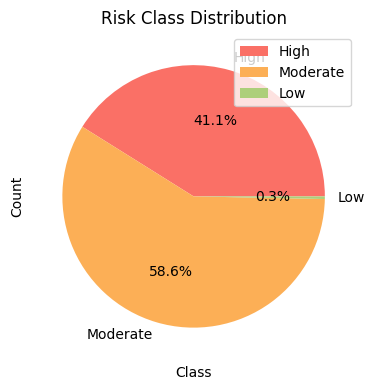

Imbalance ratio (majority/minority): 183.06 [Moderate: 11,716 vs Low: 64]


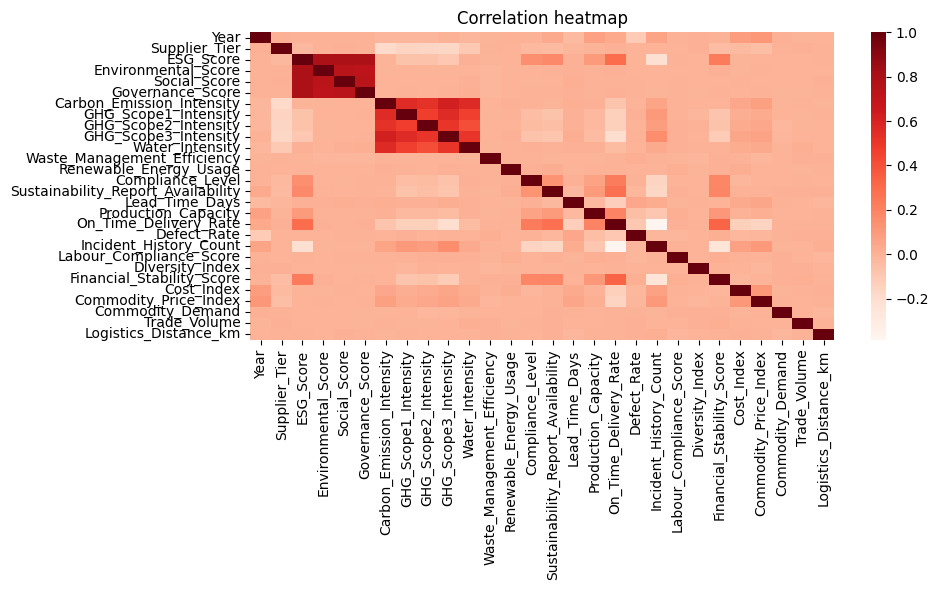

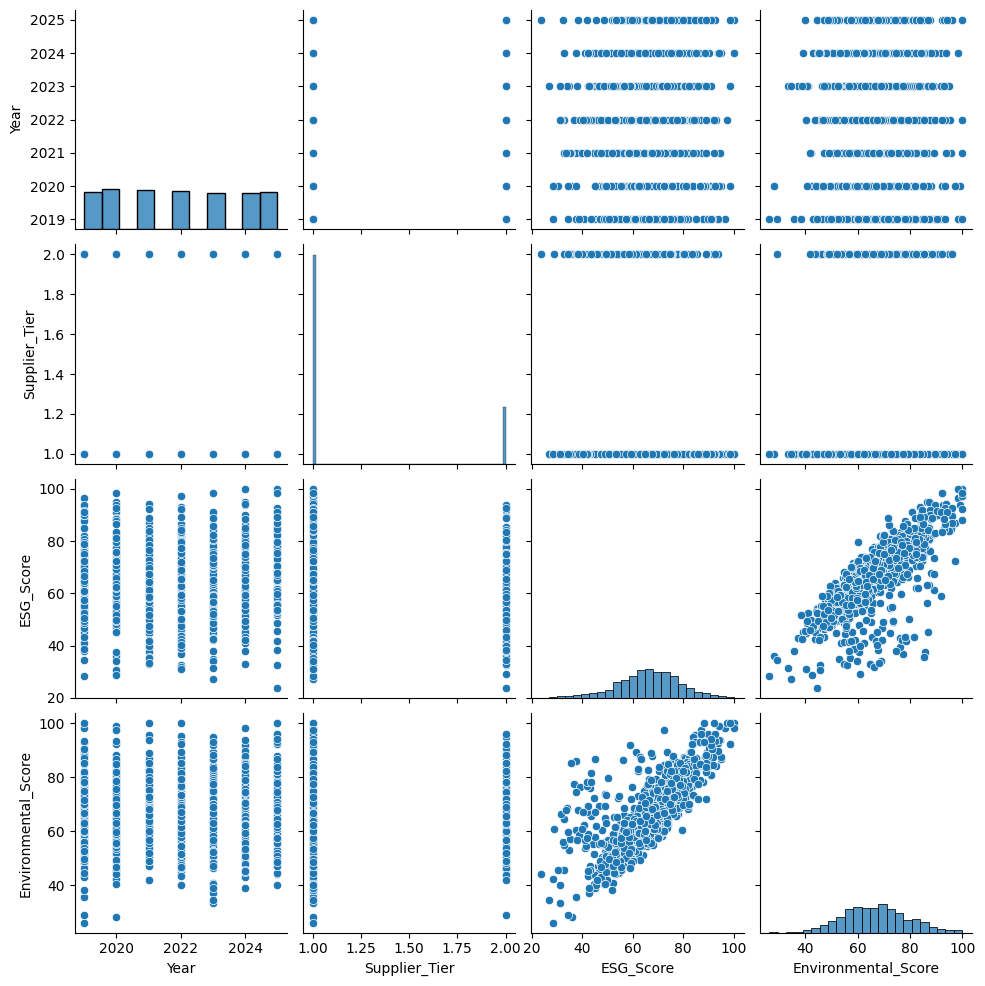

C:\Users\amtan\AppData\Local\Temp\ipykernel_34144\1913523568.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=raw_df, x=risk_col, order=order or None, palette=palette or None)


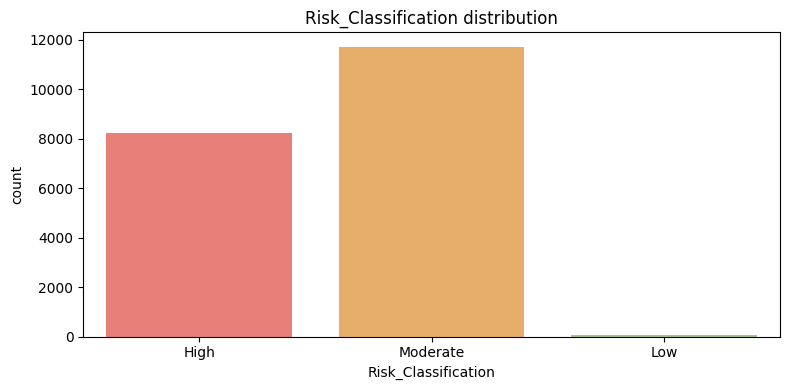

In [45]:
# Check for class imbalance
# Colour mapping for risk classes
risk_labels = ["High", "Moderate", "Low"]
risk_colours = {
    'High': "#fa7066",
    'Moderate': "#fcaf56",
    'Low': "#adcf7a",
}

print("===== CLASS IMBALANCE CHECK =====")
target_col = raw_df["Risk_Classification"]
risk_counts = target_col.value_counts().reindex(risk_labels).dropna()
risk_colours = [risk_colours[label] for label in risk_counts.index]

risk_counts.plot(kind="pie", figsize=(6, 4), autopct="%.1f%%", colors=risk_colours)
plt.title("Risk Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(risk_counts.index, loc="best")
plt.tight_layout()
plt.show()

# Calculate Imbalance Ratio of risk classes (Nikpour et al., 2025)
label_counts = target_col.value_counts()
if not label_counts.empty:
    majority_class = label_counts.idxmax()
    majority_count = label_counts.max()
    minority_class = label_counts.idxmin()
    minority_count = label_counts.min()
    imbalance_ratio = (
        majority_count / minority_count if minority_count else np.inf
    )
    print(
        f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f} "
        f"[{majority_class}: {majority_count:,} vs {minority_class}: {minority_count:,}]"
    )
else:
    print("Imbalance ratio unavailable: no labelled samples found.")

# Any relationships or patterns that can be observed now?
risk_colours = {
    "high": "#fa7066",
    "moderate": "#fcaf56",
    "low": "#adcf7a",
}

numeric_df = raw_df.select_dtypes(include=np.number)

if not numeric_df.empty:
    plt.figure(figsize=(10,6))
    sns.heatmap(numeric_df.corr(), annot=False, cmap="Reds")
    plt.title("Correlation heatmap")
    plt.tight_layout()
    plt.show()

if numeric_df.shape[1] > 1 and len(numeric_df) > 1:
    sampled_numeric = numeric_df.sample(n=min(1000, len(numeric_df)), random_state=42)
    sns.pairplot(sampled_numeric.iloc[:, :4])
    plt.show()

risk_col = next((col for col in raw_df.columns if "risk" in col.lower()), None)

if risk_col:
    order = [label for label in ["High", "Moderate", "Low"] if label in raw_df[risk_col].unique()]
    palette = {label: risk_colours[label.lower()] for label in order}
    plt.figure(figsize=(8,4))
    sns.countplot(data=raw_df, x=risk_col, order=order or None, palette=palette or None)
    plt.title(f"{risk_col} distribution")
    plt.tight_layout()
    plt.show()

### Preprocessed Synthetic Supplier-Commodity Dataset
The synthetic dataset produced after data preprocessing (data cleaning, transformation, normalisation, mapping)

### Feature engineered Synthetic Supplier-Commodity Dataset
The synthetic dataset produced after feature engineering